Algoritmos Metaheuristicos  
Examen 1 - Minimo de Funcion de Rosenbrock  
Autor: Ing. Daniel Eduardo González Alvarado  
Profesor: Dr. Marco Aceves

# Importar Librerias

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from mpl_toolkits.mplot3d import Axes3D


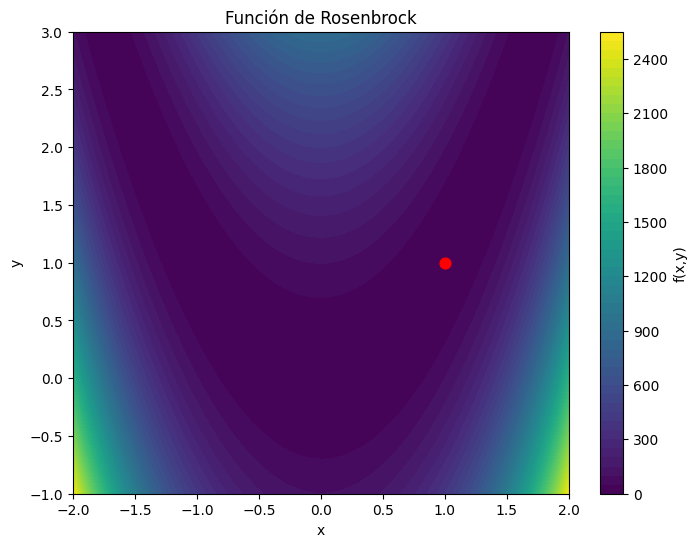

In [13]:
def rosenbrock(x, y):
    return 100 * (y - x**2)**2 + (x - 1)**2

# Malla
x = np.linspace(-2, 2, 400)
y = np.linspace(-1, 3, 400)
X, Y = np.meshgrid(x, y)
Z = rosenbrock(X, Y)

# Gráfica
plt.figure(figsize=(8,6))
plt.contourf(X, Y, Z, levels=50, cmap='viridis')
plt.colorbar(label='f(x,y)')
plt.title('Función de Rosenbrock')
plt.xlabel('x')
plt.ylabel('y')

plt.scatter(1, 1, color='red', s=60, label='Mínimo global (1,1)')

plt.show()


In [11]:
def rosenbrock(x, y):
    return 100 * (y - x**2)**2 + (x - 1)**2

x = np.linspace(-5, 10, 300)
y = np.linspace(-5, 10, 300)
X, Y = np.meshgrid(x, y)
Z = rosenbrock(X, Y)

fig = go.Figure(data=[go.Surface(z=Z, x=X, y=Y, colorscale='Viridis')])
fig.update_layout(
    title='Función de Rosenbrock (3D Interactiva)',
    scene=dict(
        xaxis_title='x₁',
        yaxis_title='x₂',
        zaxis_title='f(x₁, x₂)'
    ),
    width=800, height=700
)
fig.show()


In [23]:
X_Limit = (-5.0, 10.0) # X1 ∈ [-5,10], X2 ∈ [-5,10]
Y_Limit = (-5.0, 10.0)

Limit = np.array([[X_Limit[0], X_Limit[1]],
                   [Y_Limit[0], Y_Limit[1]]], dtype=float)

In [ ]:
def init_population(pop_size=80, rng=None):
    rng = np.random.default_rng() if rng is None else rng
    return rng.uniform(Limit[:,0], Limit[:,1], size=(pop_size, 2))

In [17]:
def fitness(pop):
    return -rosenbrock(pop[:,0], pop[:,1])  # minimizar

In [18]:
def tournament_select(pop, fit, k=3, rng=None):
    rng = np.random.default_rng() if rng is None else rng
    idx = rng.integers(0, len(pop), size=k)
    return pop[idx[np.argmax(fit[idx])]].copy()

In [19]:
def blx_alpha_crossover(p1, p2, alpha=0.3, rng=None):
    rng = np.random.default_rng() if rng is None else rng
    cmin = np.minimum(p1, p2)
    cmax = np.maximum(p1, p2)
    I = cmax - cmin
    low  = cmin - alpha * I
    high = cmax + alpha * I
    return rng.uniform(low, high)

In [ ]:
def gaussian_mutation(ind, sigma=0.05, p=0.2, rng=None):
    rng = np.random.default_rng() if rng is None else rng
    mask = rng.random(ind.shape) < p
    ind = ind + mask * rng.normal(0.0, sigma, size=ind.shape)
    return np.clip(ind, Limit[:,0], Limit[:,1])

In [21]:
def make_offspring(parents, rng=None, alpha=0.3, mut_sigma=0.05, mut_p=0.2):
    rng = np.random.default_rng() if rng is None else rng
    n = len(parents)
    children = np.zeros_like(parents)
    for i in range(0, n, 2):
        p1 = parents[i]
        p2 = parents[(i+1) % n]
        c1 = blx_alpha_crossover(p1, p2, alpha=alpha, rng=rng)
        c2 = blx_alpha_crossover(p2, p1, alpha=alpha, rng=rng)
        c1 = gaussian_mutation(c1, sigma=mut_sigma, p=mut_p, rng=rng)
        c2 = gaussian_mutation(c2, sigma=mut_sigma, p=mut_p, rng=rng)
        children[i] = c1
        if i+1 < n: children[i+1] = c2
    return children

In [36]:
def surface_background(ax, res=120):
    xs = np.linspace(Limit[0,0], Limit[0,1], res)
    ys = np.linspace(Limit[1,0], Limit[1,1], res)
    X, Y = np.meshgrid(xs, ys)
    Z = rosenbrock(X, Y)

    # Colormap viridis
    surf = ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.8, linewidth=0, antialiased=True)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("f(x,y)")
    ax.set_title("Evolución GA en Rosenbrock (3D)")
    
    # Barra de color opcional
    fig = ax.get_figure()
    fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, label="f(x,y)")
    return ax

# Grafica

In [38]:
def plot_population_3d(pop, best, gen, best_val):
    fig = plt.figure(figsize=(7,6))
    ax = fig.add_subplot(111, projection='3d')
    surface_background(ax, res=120)

    # Población
    z = rosenbrock(pop[:,0], pop[:,1])
    ax.scatter(pop[:,0], pop[:,1], z, s=18, color='black', alpha=0.6, label='Población')

    # Mejor individuo
    ax.scatter([best[0]], [best[1]], [best_val],
               s=120, marker="*", color='red', edgecolor='white', linewidth=1.2,
               label=f"Mejor gen {gen}\n f={best_val:.4e}")

    ax.legend(loc='upper left')
    ax.set_xlim(*X_Limit)
    ax.set_ylim(*Y_Limit)
    plt.show()

In [40]:
def run_ga(pop_size=120, generations=180, plot_every=20, k_tourn=3, elite_frac=0.05, rng_seed=7):
    rng = np.random.default_rng(rng_seed)
    pop = init_population(pop_size, rng)
    fit = fitness(pop)

    elite_count = max(1, int(pop_size * elite_frac))
    history_best = []
    history_xy = []

    for gen in range(1, generations+1):
        # elitismo
        order = np.argsort(-fit)
        elites = pop[order[:elite_count]].copy()

        # selección y reproducción
        parents = np.array([tournament_select(pop, fit, k=k_tourn, rng=rng) for _ in range(pop_size)])
        mut_sigma = np.interp(gen, [1, generations], [0.12, 0.01])
        children = make_offspring(parents, rng=rng, alpha=0.35, mut_sigma=mut_sigma, mut_p=0.25)
        children[:elite_count] = elites
        children = np.clip(children, Limit[:,0], Limit[:,1])

        pop = children
        fit = fitness(pop)

        # métrica
        i = np.argmax(fit)
        best_xy = pop[i].copy()
        best_val = rosenbrock(best_xy[0], best_xy[1])
        history_best.append(best_val); history_xy.append(best_xy)

        if gen == 1 or gen % plot_every == 0:
            plot_population_3d(pop, best_xy, gen, best_val)

    # curva de convergencia
    fig = plt.figure(figsize=(7,4))
    plt.plot(history_best)
    plt.xlabel("Generación"); plt.ylabel("Mejor f(x,y)")
    plt.title("Convergencia (mejor por generación)")
    plt.grid(True); plt.show()

    bgen = int(np.argmin(history_best))
    bxy  = history_xy[bgen]
    bval = history_best[bgen]
    print(f"Mejor solución: x={bxy[0]:.6f}, y={bxy[1]:.6f}, f={bval:.6e} (gen {bgen+1})")
    return np.array(history_best), np.array(history_xy)


# Start

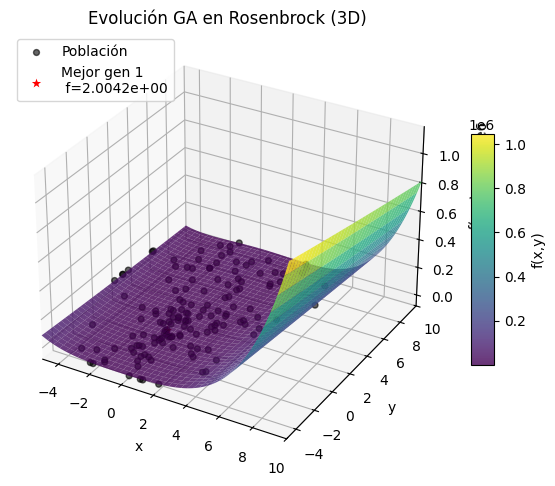

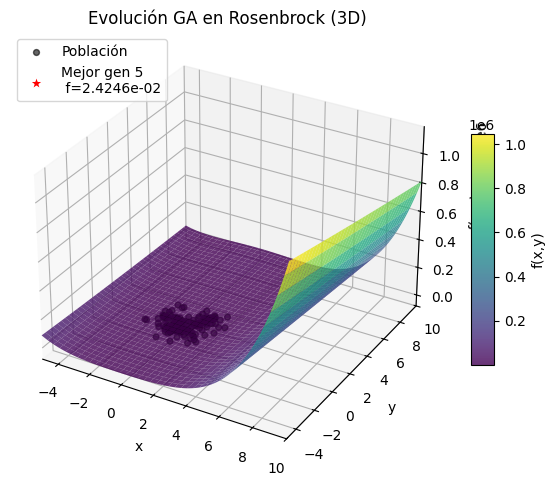

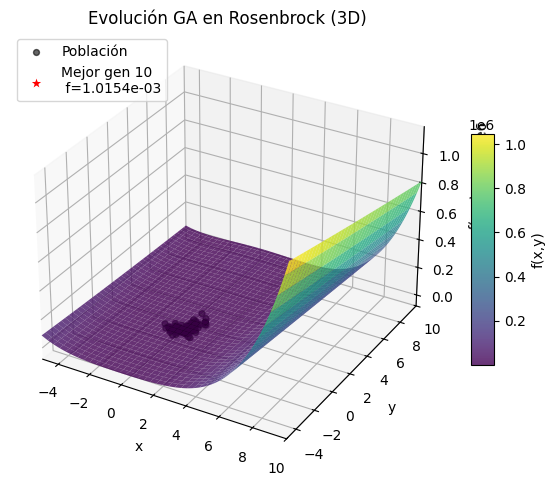

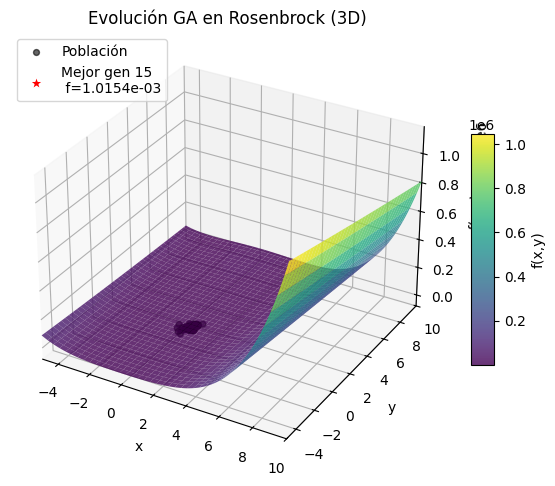

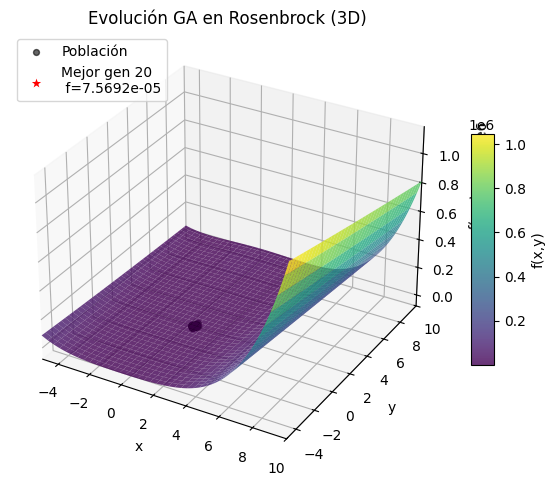

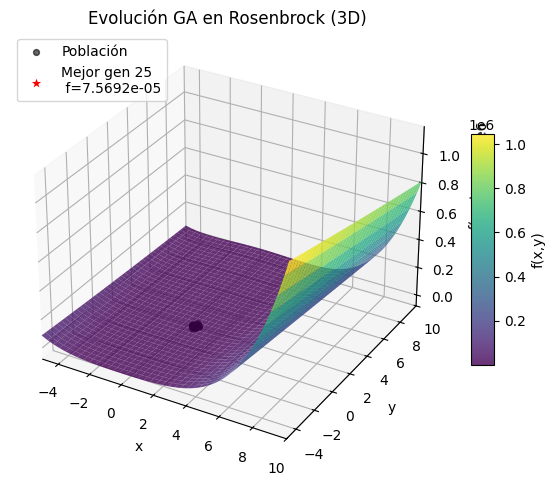

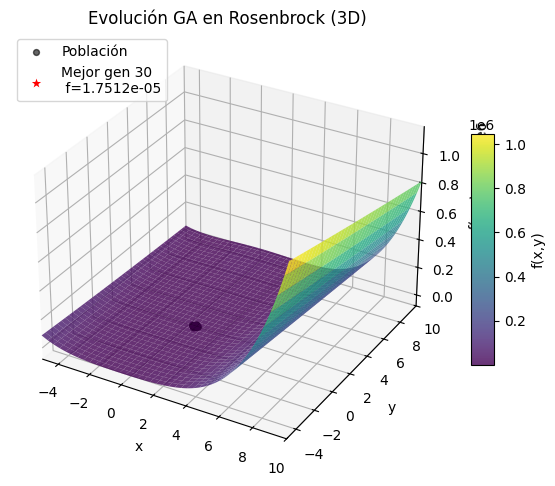

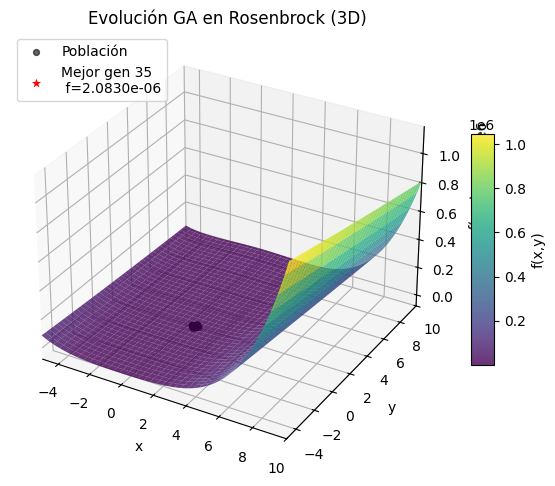

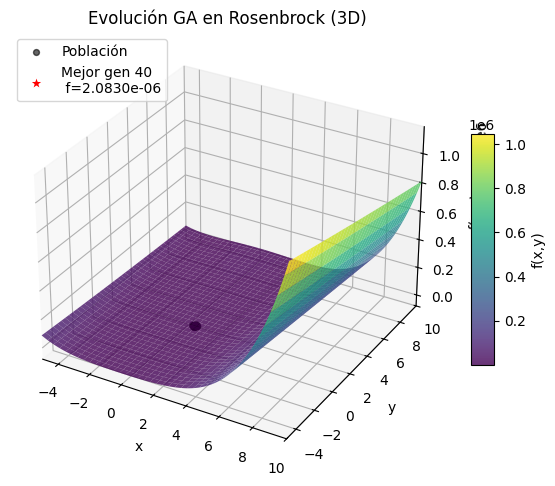

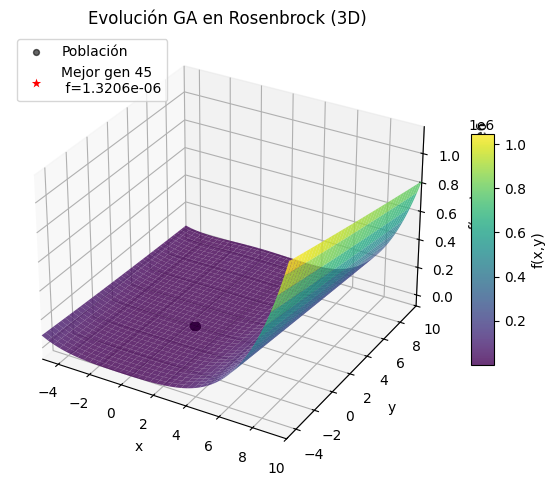

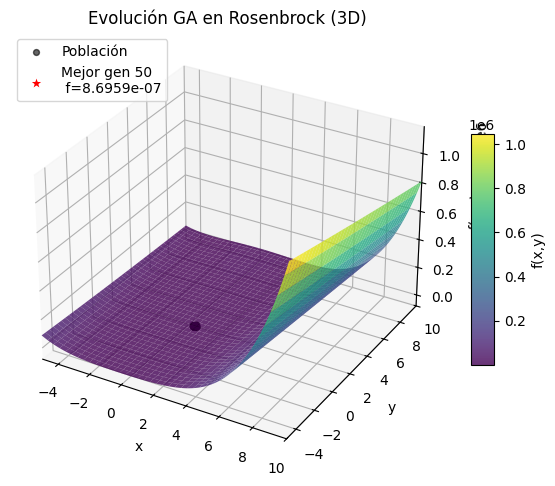

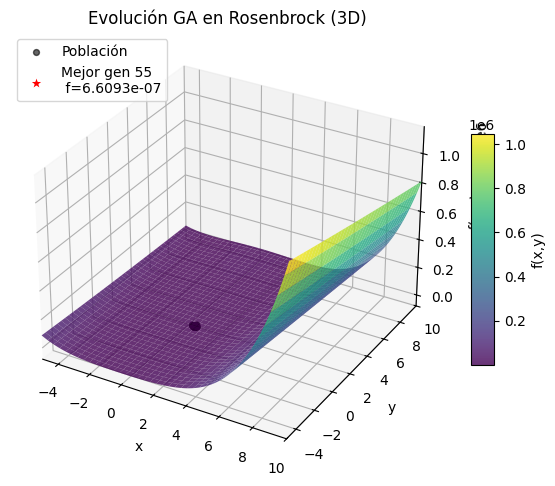

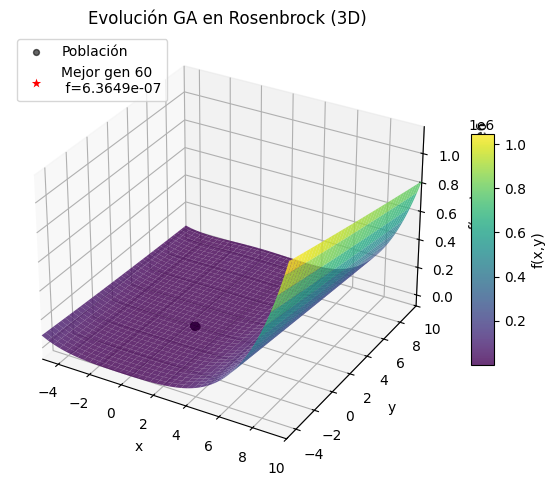

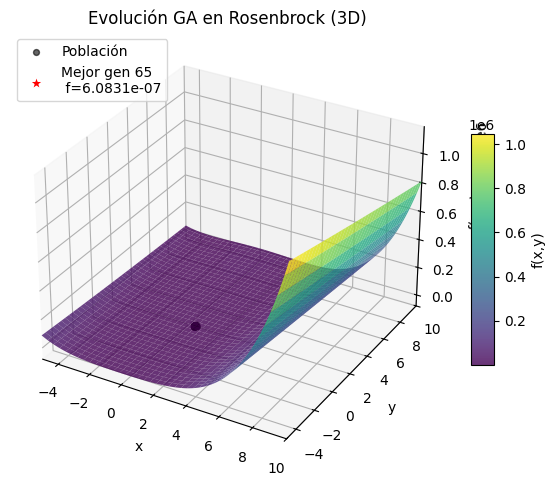

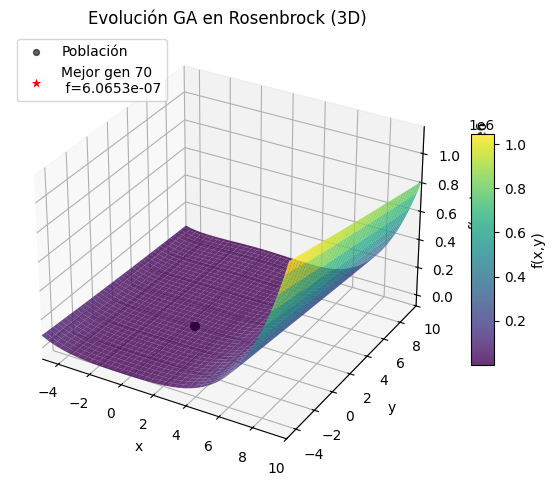

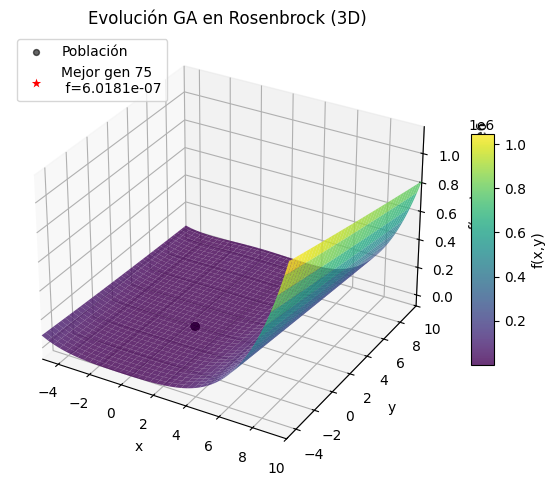

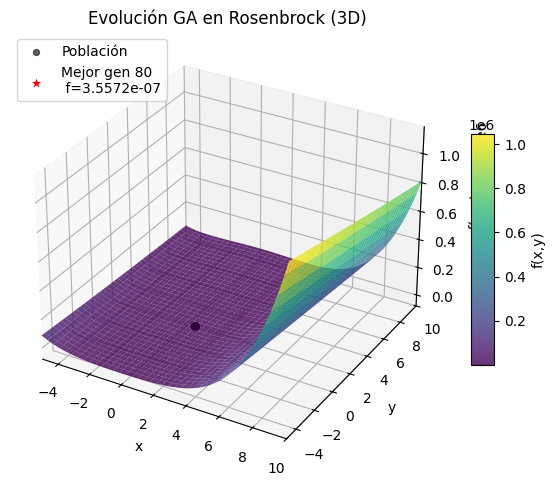

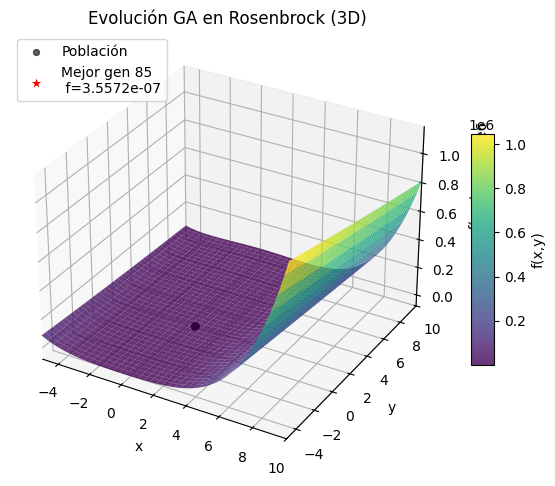

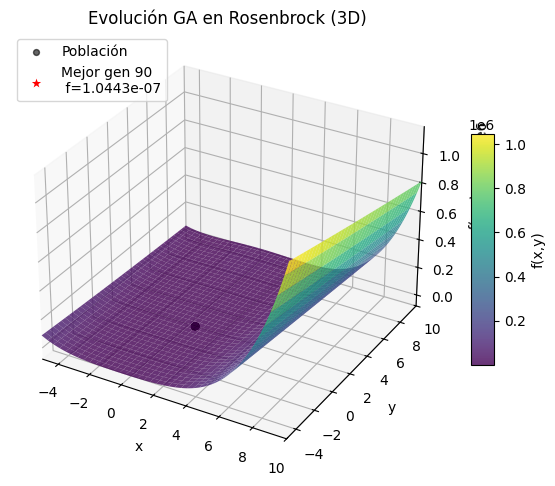

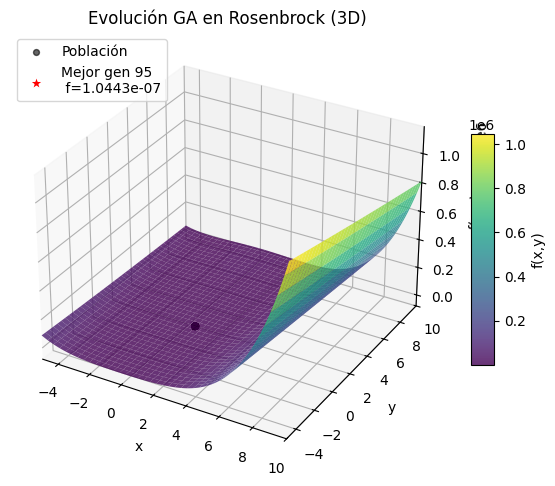

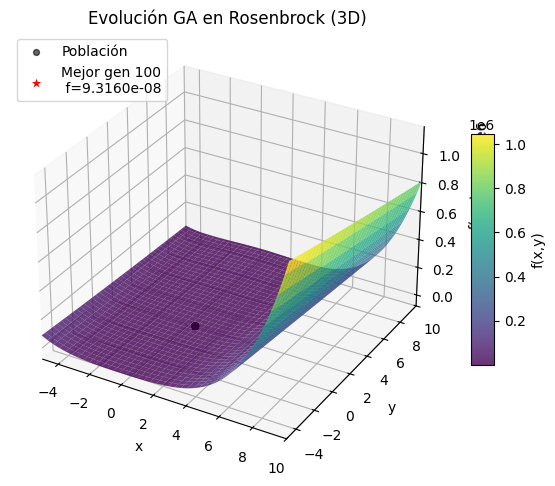

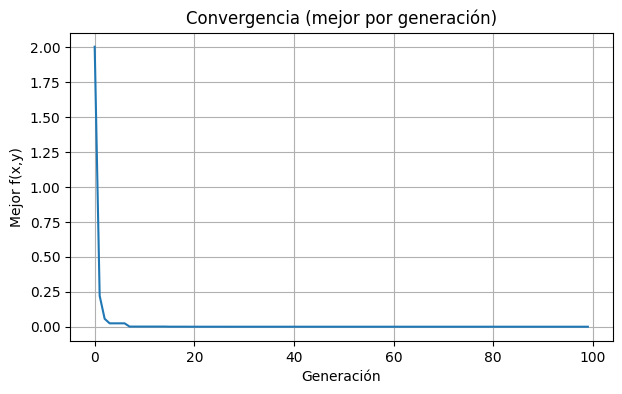

Mejor solución: x=0.999703, y=0.999414, f=9.316011e-08 (gen 96)


In [39]:
history_best, history_xy = run_ga(pop_size=150, generations=100, plot_every=5, k_tourn=3, elite_frac=0.06, rng_seed=2025)